In [7]:
# 🔷 Step 1: Import libraries

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [8]:
# 🔷 Step 2: Load dataset

df = pd.read_csv("data-sets/Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
# 🔷 Step 3: Select features

X = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

In [10]:
# 🔷 Step 4: Feature scaling (VERY IMPORTANT for PCA)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
# 🔷 Step 5: Apply PCA (2 components)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_pca[:5]

array([[-0.61572002, -1.76348088],
       [-1.66579271, -1.82074695],
       [ 0.33786191, -1.67479894],
       [-1.45657325, -1.77242992],
       [-0.03846521, -1.66274012]])

In [13]:
# 🔷 Step 6: Apply K-Means

kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_pca)

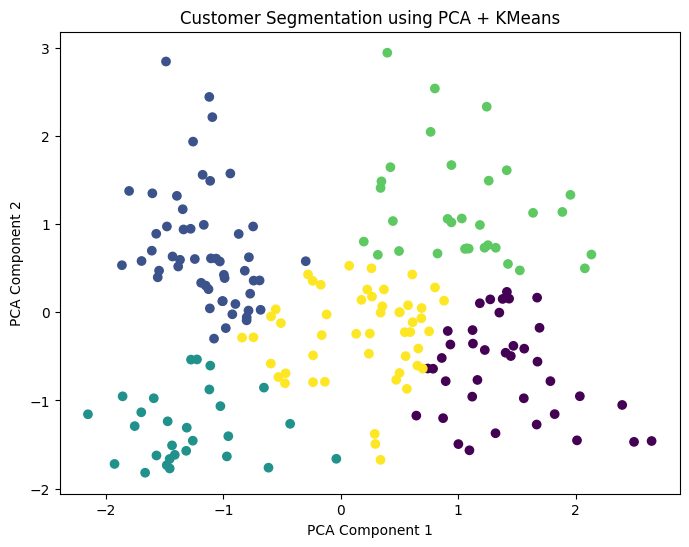

In [15]:
# 🔷 Step 7: Plot clusters

plt.figure(figsize=(8,6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segmentation using PCA + KMeans")

plt.show()

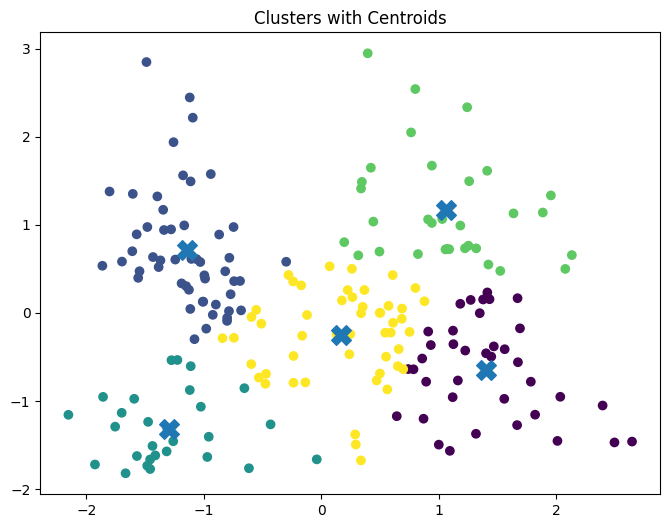

In [16]:
# 🔷 Step 8: Plot cluster centers (optional but good)

centers = kmeans.cluster_centers_

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans)
plt.scatter(centers[:, 0], centers[:, 1], s=200, marker='X')

plt.title("Clusters with Centroids")
plt.show()

In [ ]:
# 🧠 What’s happening internally (quick intuition)
# Scaling → puts all features on same scale
# PCA → compresses data into 2 directions with max variance
# K-Means → groups similar customers
# Plot → shows clusters visually